**Electric Vehicle Population Analysis using Python**

#Project Overview
- This project analyzes the Electric Vehicle Population dataset using Python. The analysis focuses on understanding electric vehicle distribution, manufacturers, model years, vehicle types, electric range, and geographical trends through data cleaning, exploratory data analysis (EDA), and visualizations.

In [29]:
#importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load the Dataset**

In [30]:
df=pd.read_csv("Electric_Vehicle_Population_Data.csv")
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,KM8K33AGXL,King,Seattle,WA,98103.0,2020,HYUNDAI,KONA,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,258,0,43.0,249675142,POINT (-122.34301 47.659185),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
1,1C4RJYB61N,King,Bothell,WA,98011.0,2022,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25,0,1.0,233928502,POINT (-122.20578 47.762405),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
2,1C4RJYD61P,Yakima,Yakima,WA,98908.0,2023,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25,0,14.0,229675939,POINT (-120.6027202 46.5965625),PACIFICORP,5.307700e+10
3,5YJ3E1EA7J,King,Kirkland,WA,98034.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215,0,45.0,104714466,POINT (-122.209285 47.71124),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
4,WBY7Z8C5XJ,Thurston,Olympia,WA,98501.0,2018,BMW,I3,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,97,0,22.0,185498386,POINT (-122.89692 47.043535),PUGET SOUND ENERGY INC,5.306701e+10


In [31]:
df.shape


(150482, 17)

In [32]:
df.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District', 'DOL Vehicle ID',
       'Vehicle Location', 'Electric Utility', '2020 Census Tract'],
      dtype='object')

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150482 entries, 0 to 150481
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         150482 non-null  object 
 1   County                                             150479 non-null  object 
 2   City                                               150479 non-null  object 
 3   State                                              150482 non-null  object 
 4   Postal Code                                        150479 non-null  float64
 5   Model Year                                         150482 non-null  int64  
 6   Make                                               150482 non-null  object 
 7   Model                                              150482 non-null  object 
 8   Electric Vehicle Type                              150482 non-null  object

**Checking missing values**

In [34]:
df.isnull().sum()

VIN (1-10)                                             0
County                                                 3
City                                                   3
State                                                  0
Postal Code                                            3
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         0
Base MSRP                                              0
Legislative District                                 341
DOL Vehicle ID                                         0
Vehicle Location                                       7
Electric Utility                                       3
2020 Census Tract                                      3
dtype: int64

**cheking Duplicate values**

In [35]:
df.duplicated().sum()

np.int64(0)

**removing duplicate values**

In [36]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

**Data Cleaning**

In [37]:
df.drop_duplicates(inplace=True)

In [38]:
df.shape

(150482, 17)

**Handle Missing Values**

In [39]:
# Check missing values
df.isnull().sum()
# Remove rows having missing values
df = df.dropna()


**Remove Unnecessary Columns**

In [40]:
df = df.drop(columns=[
    "VIN (1-10)",
    "DOL Vehicle ID",
    "2020 Census Tract"
])

**Convert Data Types**(model year integer)

In [41]:
df["Model Year"] = df["Model Year"].astype(int)
df["Electric Range"] = pd.to_numeric(
    df["Electric Range"],
    errors="coerce"
)
df["Postal Code"] = df["Postal Code"].astype(str)

**Remove Duplicate Records**


In [42]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

**Check Dataset After Cleaning**

In [43]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
Index: 51500 entries, 0 to 150480
Data columns (total 14 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   County                                             51500 non-null  object 
 1   City                                               51500 non-null  object 
 2   State                                              51500 non-null  object 
 3   Postal Code                                        51500 non-null  object 
 4   Model Year                                         51500 non-null  int64  
 5   Make                                               51500 non-null  object 
 6   Model                                              51500 non-null  object 
 7   Electric Vehicle Type                              51500 non-null  object 
 8   Clean Alternative Fuel Vehicle (CAFV) Eligibility  51500 non-null  object 
 9   Electric R

(51500, 14)

# Exploratory Data Analysis (EDA)

- Exploratory Data Analysis (EDA) is performed to understand the characteristics of the Electric Vehicle Population dataset. This analysis helps identify trends, distributions, and patterns in electric vehicle registrations using various statistical summaries and visualizations.

In [44]:
#Dataset Overview
df.head()

,County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,Vehicle Location,Electric Utility
0,King,Seattle,WA,98103.0,2020,HYUNDAI,KONA,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,258,0,43.0,POINT (-122.34301 47.659185),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)
1,King,Bothell,WA,98011.0,2022,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25,0,1.0,POINT (-122.20578 47.762405),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
2,Yakima,Yakima,WA,98908.0,2023,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25,0,14.0,POINT (-120.6027202 46.5965625),PACIFICORP
3,King,Kirkland,WA,98034.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215,0,45.0,POINT (-122.209285 47.71124),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
4,Thurston,Olympia,WA,98501.0,2018,BMW,I3,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,97,0,22.0,POINT (-122.89692 47.043535),PUGET SOUND ENERGY INC


Observation
- The dataset contains information about electric vehicles, including manufacturer, model, model year, electric range, vehicle type, and location details.

**Number of Vehicles by Manufacturer**

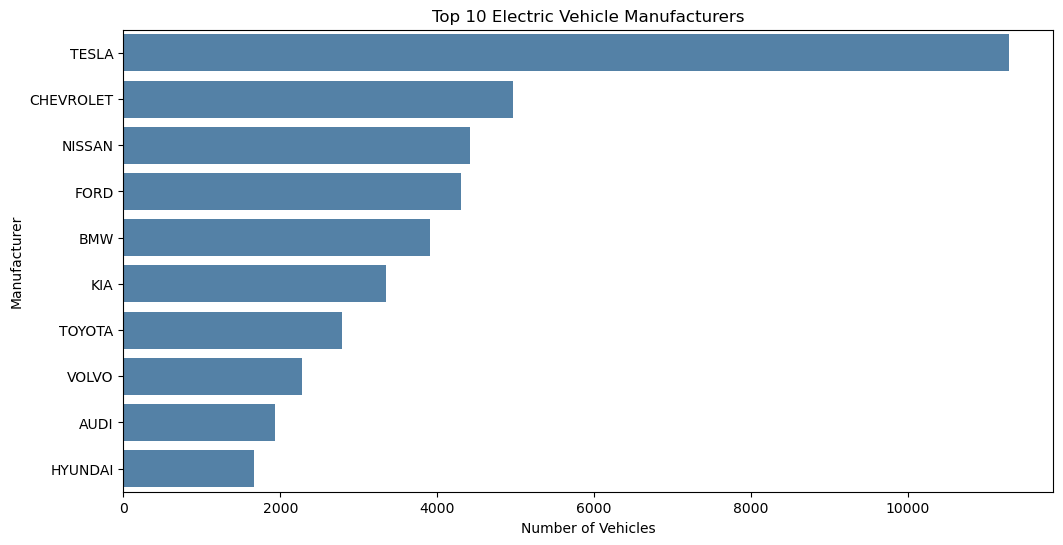

In [47]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="Make",
    order=df["Make"].value_counts().head(10).index,
    color="steelblue"
)

plt.title("Top 10 Electric Vehicle Manufacturers")
plt.xlabel("Number of Vehicles")
plt.ylabel("Manufacturer")

plt.show()

Observation
- Tesla has the highest number of registered electric vehicles, followed by Nissan, Chevrolet, Ford, and BMW.

**Top 10 Vehicle Models**

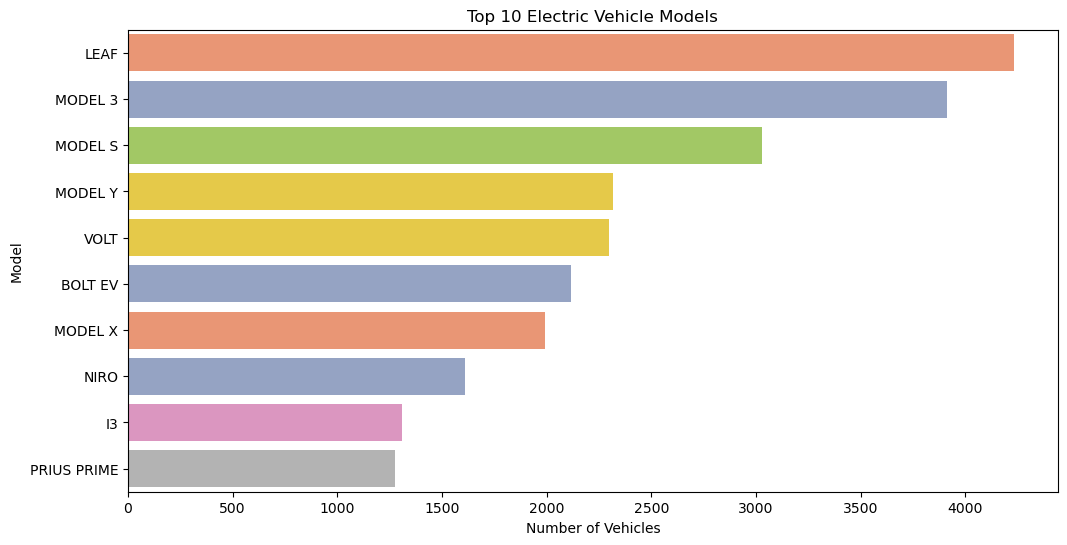

In [48]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="Model",
    hue="Model",
    order=df["Model"].value_counts().head(10).index,
    palette="Set2",
    legend=False
)

plt.title("Top 10 Electric Vehicle Models")
plt.xlabel("Number of Vehicles")
plt.ylabel("Model")

plt.show()

Observation
- The dataset is dominated by a few popular electric vehicle models, indicating higher customer preference for these models.

**Top 10 Cities**

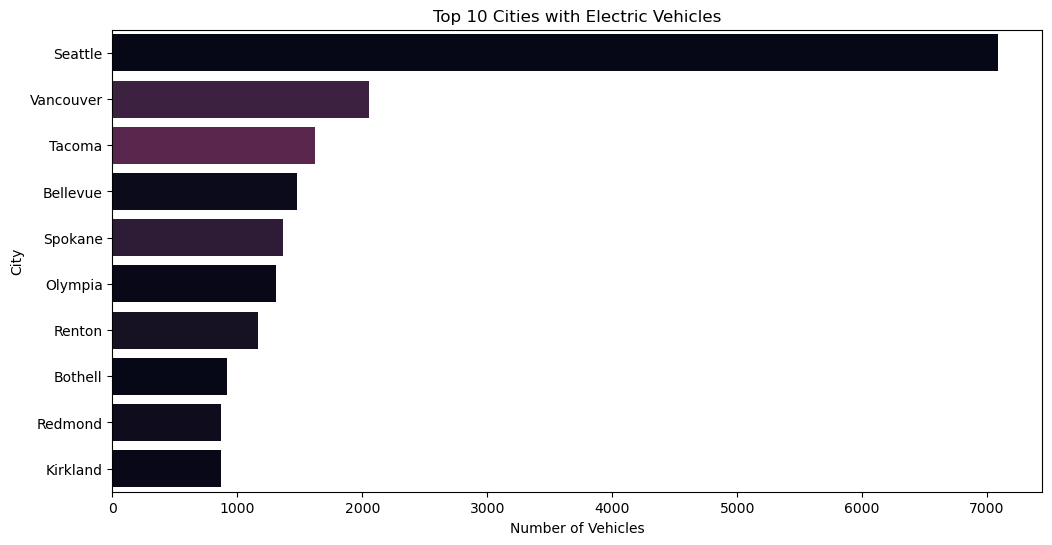

In [50]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="City",
    hue="City",
    order=df["City"].value_counts().head(10).index,
    palette="rocket",
    legend=False
)

plt.title("Top 10 Cities with Electric Vehicles")
plt.xlabel("Number of Vehicles")
plt.ylabel("City")

plt.show()

Observation
- A small number of cities account for a large share of electric vehicle registrations.

**Model Year Distribution**

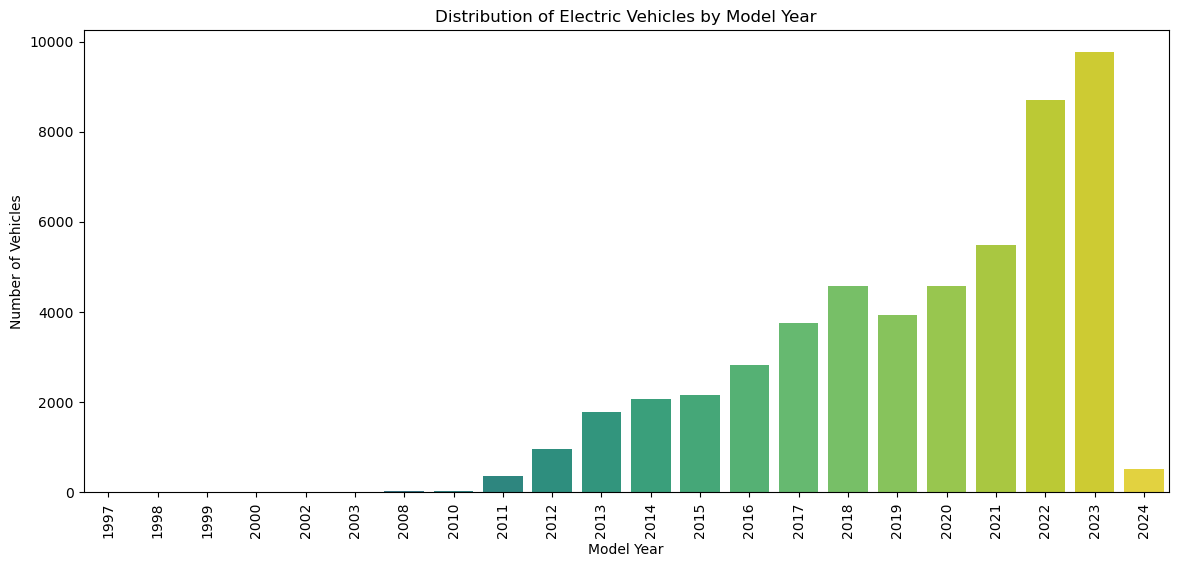

In [52]:
plt.figure(figsize=(14,6))

sns.countplot(
    data=df,
    x="Model Year",
    hue="Model Year",
    palette="viridis",
    legend=False
)

plt.xticks(rotation=90)

plt.title("Distribution of Electric Vehicles by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Number of Vehicles")

plt.show()

Observation
- Electric vehicle registrations have increased significantly in recent model years, reflecting the growing adoption of EV technology.

**Electric Vehicle Type**

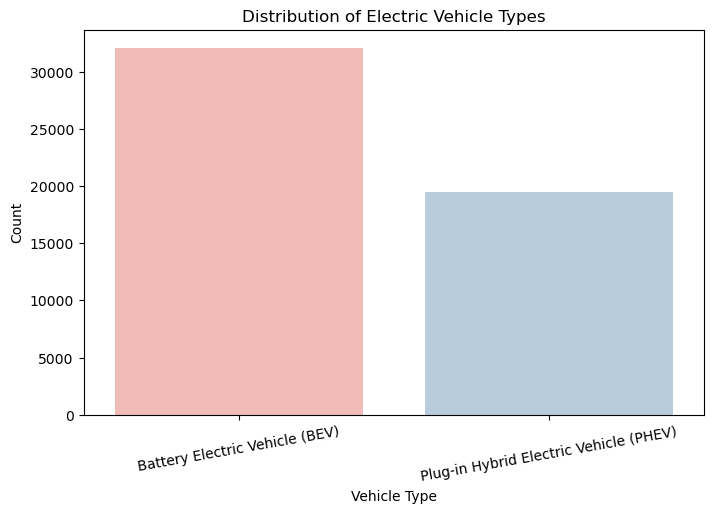

In [54]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Electric Vehicle Type",
    hue="Electric Vehicle Type",
    palette="Pastel1",
    legend=False
)

plt.xticks(rotation=10)

plt.title("Distribution of Electric Vehicle Types")
plt.xlabel("Vehicle Type")
plt.ylabel("Count")

plt.show()

Observation
- Battery Electric Vehicles (BEVs) represent a larger share of the dataset than Plug-in Hybrid Electric Vehicles (PHEVs).

**Top 10 Counties**

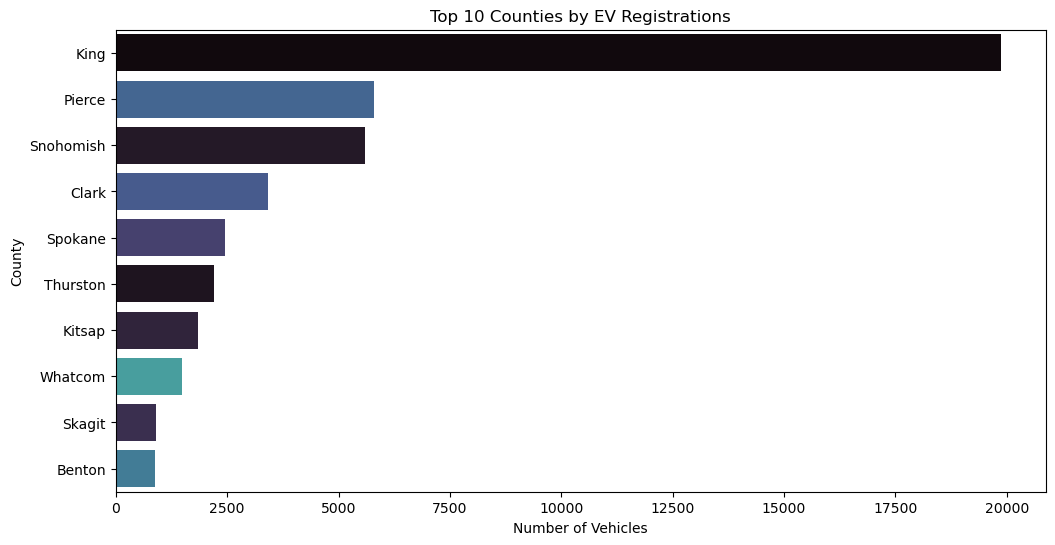

In [55]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="County",
    hue="County",
    order=df["County"].value_counts().head(10).index,
    palette="mako",
    legend=False
)

plt.title("Top 10 Counties by EV Registrations")
plt.xlabel("Number of Vehicles")
plt.ylabel("County")

plt.show()

Observation
- Only a few counties contribute a significant portion of the total electric vehicle registrations.

**Electric Range Distribution**

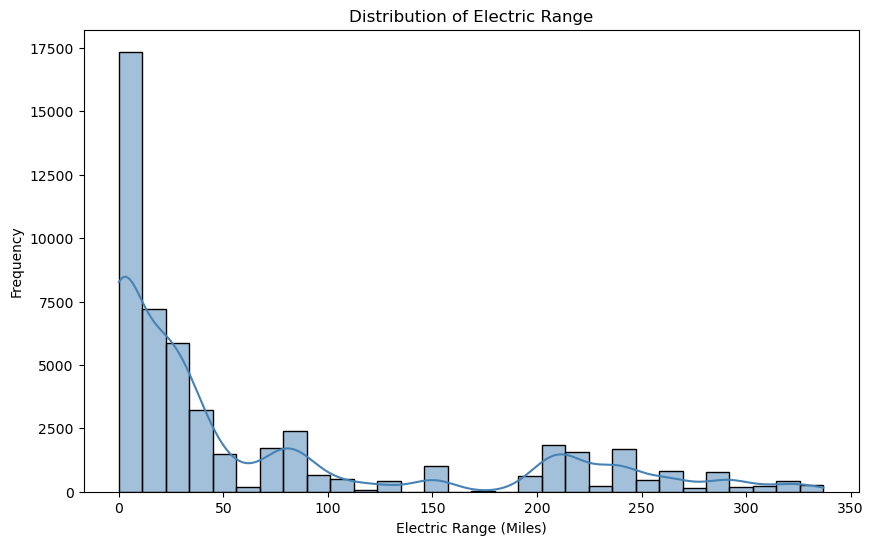

In [57]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Electric Range",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Electric Range")
plt.xlabel("Electric Range (Miles)")
plt.ylabel("Frequency")

plt.show()

Observation
- Most electric vehicles offer a moderate driving range, while fewer vehicles provide very high electric range.

**Average Electric Range by Manufacturer**

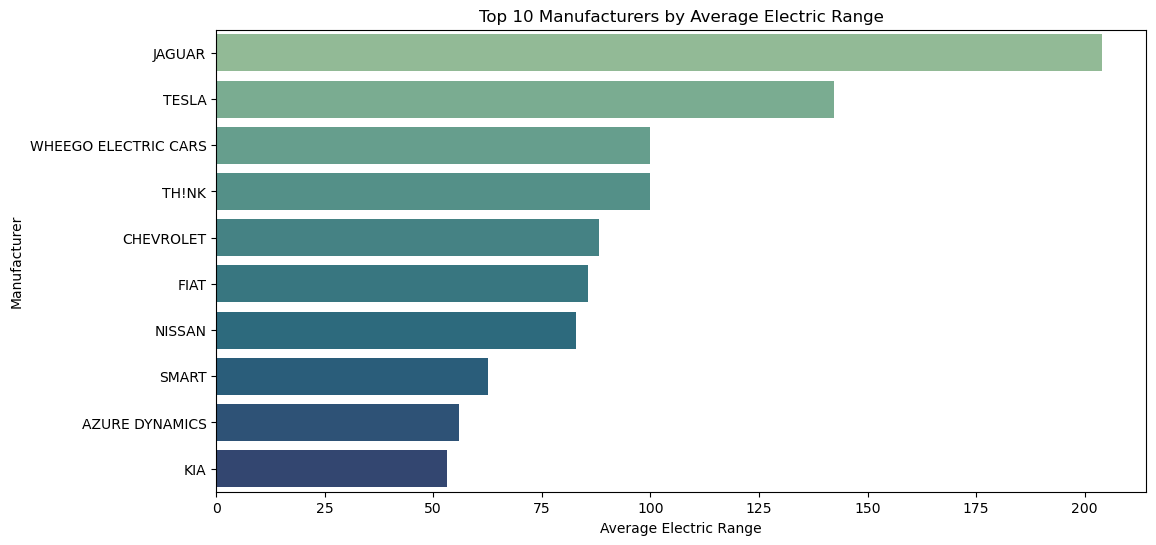

In [58]:
avg_range = (
    df.groupby("Make")["Electric Range"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=avg_range.values,
    y=avg_range.index,
    hue=avg_range.index,
    palette="crest",
    legend=False
)

plt.title("Top 10 Manufacturers by Average Electric Range")
plt.xlabel("Average Electric Range")
plt.ylabel("Manufacturer")

plt.show()

Observation
- Some manufacturers produce vehicles with a considerably higher average electric driving range than others.

**Correlation Heatmap**

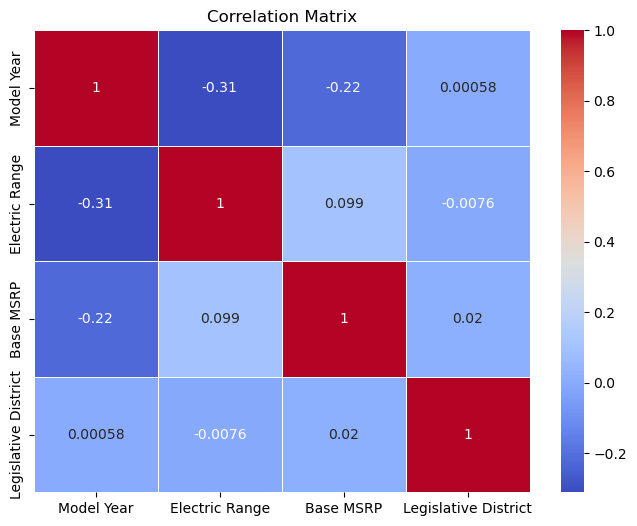

In [60]:
numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

Observation
- The heatmap illustrates the relationship between numerical variables such as Model Year, Electric Range, Base MSRP, and Legislative District.

**Top 10 Electric Utility Companies**

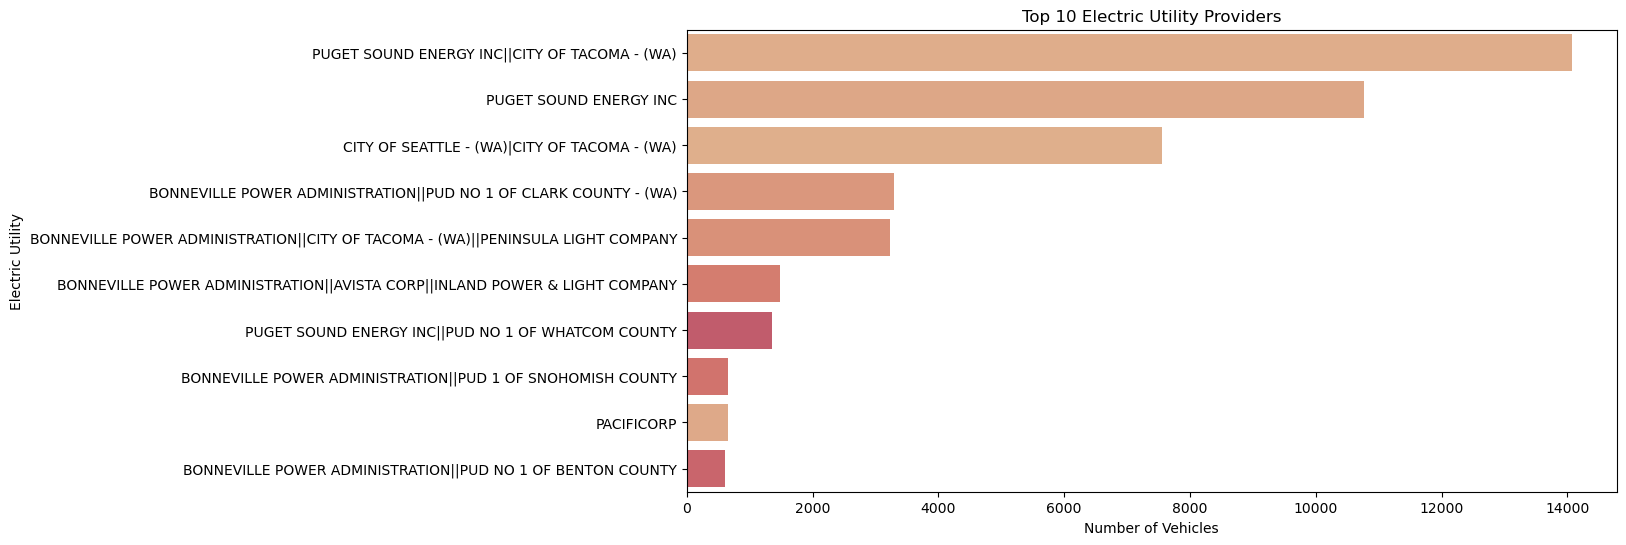

In [61]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="Electric Utility",
    hue="Electric Utility",
    order=df["Electric Utility"].value_counts().head(10).index,
    palette="flare",
    legend=False
)

plt.title("Top 10 Electric Utility Providers")
plt.xlabel("Number of Vehicles")
plt.ylabel("Electric Utility")

plt.show()

Observation
- A few electric utility providers serve the majority of registered electric vehicles in the dataset.

**Electric Range Box Plot**

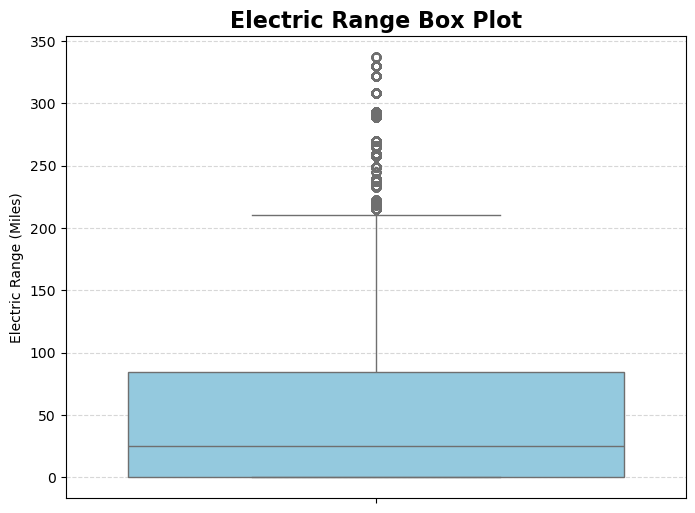

In [63]:
plt.figure(figsize=(8,6))

sns.boxplot(
    y=df["Electric Range"],
    color="skyblue"
)

plt.title("Electric Range Box Plot", fontsize=16, fontweight="bold")
plt.ylabel("Electric Range (Miles)")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

Observation
- The box plot shows the distribution of electric vehicle driving range. Most vehicles fall within a moderate electric range, while a few vehicles with exceptionally high or low ranges appear as outliers.

# Business Insights

- Tesla is one of the leading electric vehicle manufacturers, indicating its strong market presence.
- Battery Electric Vehicles (BEVs) are more popular than Plug-in Hybrid Electric Vehicles (PHEVs).
- Electric vehicle registrations have increased significantly in recent model years, reflecting the growing demand for sustainable transportation.
- A few cities and counties contribute to a large share of EV registrations, showing regional concentration.
- Manufacturers offering higher electric driving ranges are likely to attract more customers seeking longer travel distances.
- Electric utility providers play an important role in supporting EV adoption across different regions.

# Key Findings

- The dataset contains 51,500 cleaned records after preprocessing.
- Tesla dominates the electric vehicle market in terms of registrations.
- Most registered vehicles are Battery Electric Vehicles (BEVs).
- EV registrations have grown rapidly over the last few years.
- Electric driving range varies across different manufacturers and vehicle models.
- Electric vehicle adoption is concentrated in major cities and counties.

# Conclusion

This project analyzed the Electric Vehicle Population dataset using Python for data cleaning, exploratory data analysis, and visualization. The analysis revealed significant growth in electric vehicle adoption, with Battery Electric Vehicles (BEVs) being the most common type. The results also highlighted leading manufacturers, regional distribution, and variations in electric driving range. Overall, the project demonstrates how data analysis can provide meaningful insights into the expanding electric vehicle market and support data-driven decision-making.